In [26]:
pip install yfinance pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


LIBRARIES IMPORT

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

STOCK DATA DOWNLOAD

In [7]:
stocks = ["AAPL","MSFT","TSLA","AMZN"]
data = yf.download(stocks,start="2020-01-01",end="2024-01-01")
data.head()

[*********************100%***********************]  4 of 4 completed


Price           Close                                         High             \
Ticker           AAPL       AMZN        MSFT       TSLA       AAPL       AMZN   
Date                                                                            
2020-01-02  72.400513  94.900497  152.158386  28.684000  72.460776  94.900497   
2020-01-03  71.696632  93.748497  150.263748  29.534000  72.455950  94.309998   
2020-01-06  72.267960  95.143997  150.652145  30.102667  72.306529  95.184502   
2020-01-07  71.928055  95.343002  149.278519  31.270666  72.533095  95.694504   
2020-01-08  73.085106  94.598503  151.656357  32.809334  73.386423  95.550003   

Price                                    Low                         \
Ticker            MSFT       TSLA       AAPL       AMZN        MSFT   
Date                                                                  
2020-01-02  152.262592  28.713333  71.156674  93.207497  149.989032   
2020-01-03  151.523684  30.266666  71.472454  93.224998  149.733252   
2020-01-06  150.718465  30.104000  70.568532  93.000000  148.264897   
2020-01-07  151.258412  31.441999  71.708695  94.601997  149.032221   
2020-01-08  152.328960  33.232666  71.631552  94.321999  149.629094   

Price                       Open                                       Volume  \
Ticker           TSLA       AAPL       AMZN        MSFT       TSLA       AAPL   
Date                                                                            
2020-01-02  28.114000  71.409778  93.750000  150.415323  28.299999  135480400   
2020-01-03  29.128000  71.629138  93.224998  149.979564  29.366667  146322800   
2020-01-06  29.333332  70.819231  93.000000  148.804876  29.364668  118387200   
2020-01-07  30.224001  72.277578  95.224998  150.926859  30.760000  108872000   
2020-01-08  31.215334  71.631552  94.902000  150.557463  31.580000  132079200   

Price                                      
Ticker          AMZN      MSFT       TSLA  
Date                                       
2020-01-02  80580000  22622100  142981500  
2020-01-03  75288000  21116200  266677500  
2020-01-06  81236000  20813700  151995000  
2020-01-07  80898000  21634100  268231500  
2020-01-08  70160000  27746500  467164500

CLOSE PRICE

In [8]:
close_price =data["Close"]
close_price.head()

Ticker,AAPL,AMZN,MSFT,TSLA
Date,,,,
2020-01-02,72.400513,94.900497,152.158386,28.684000
2020-01-03,71.696632,93.748497,150.263748,29.534000
2020-01-06,72.267960,95.143997,150.652145,30.102667
2020-01-07,71.928055,95.343002,149.278519,31.270666
2020-01-08,73.085106,94.598503,151.656357,32.809334


DAILY RETURNS CALCULATIONS

In [9]:
returns = close_price.pct_change()
returns.head()

Ticker,AAPL,AMZN,MSFT,TSLA
Date,,,,
2020-01-02,NaN,NaN,NaN,NaN
2020-01-03,-0.009722,-0.012139,-0.012452,0.029633
2020-01-06,0.007969,0.014886,0.002585,0.019255
2020-01-07,-0.004703,0.002092,-0.009118,0.038801
2020-01-08,0.016086,-0.007809,0.015929,0.049205


RETURNS CHART

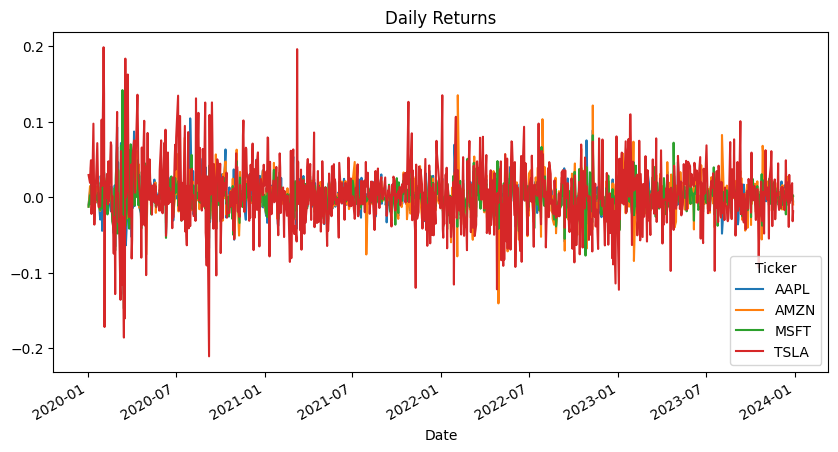

In [12]:
returns.plot(figsize=(10,5))
plt.title("Daily Returns")
plt.show()

VOLATILITY(RISK MEASURE)

In [13]:
volatility =returns.std()
volatility

Ticker
AAPL    0.021146
AMZN    0.023741
MSFT    0.020546
TSLA    0.042902
dtype: float64

VOLATILITY CHART

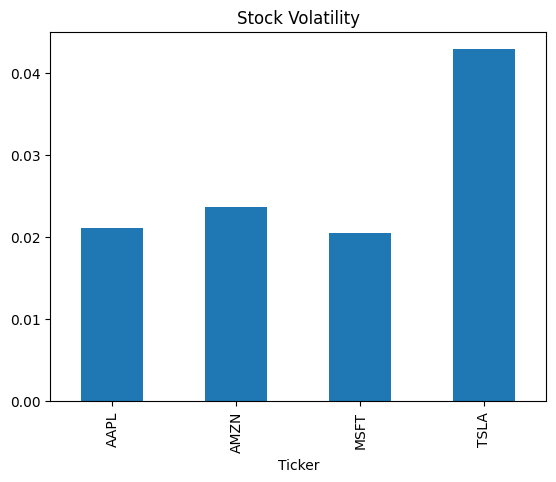

In [14]:
volatility.plot(kind="bar")
plt.title("Stock Volatility")
plt.show()

CORRELATION MATRIX

In [15]:
correlation = returns.corr()
correlation

Ticker,AAPL,AMZN,MSFT,TSLA
Ticker,,,,
AAPL,1.000000,0.624233,0.777003,0.510815
AMZN,0.624233,1.000000,0.679093,0.454191
MSFT,0.777003,0.679093,1.000000,0.472155
TSLA,0.510815,0.454191,0.472155,1.000000


CORRELATION HEATMAP(VISUALIZATION)

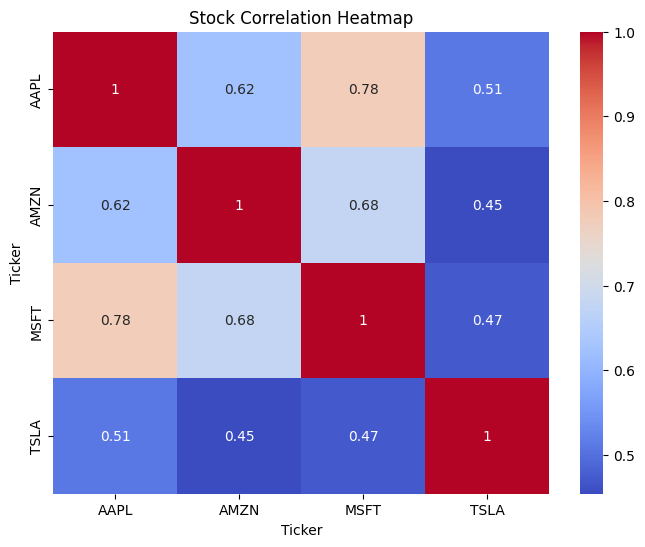

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation,annot=True,cmap="coolwarm")
plt.title("Stock Correlation Heatmap")
plt.show()

APPLE STOCK

In [17]:
apple=close_price["AAPL"]
apple.head()

Date
2020-01-02    72.400513
2020-01-03    71.696632
2020-01-06    72.267960
2020-01-07    71.928055
2020-01-08    73.085106
Name: AAPL, dtype: float64

DAILY RETURN MEAN & STD

In [19]:
daily_return =apple.pct_change()
mean=daily_return.mean()
std=daily_return.std()
print(mean,std)

0.0011865675690976313 0.021145928569203852


SIMULATION PARAMETERS

In [20]:
simulations=1000
days=252
last_price=apple.iloc[-1]

SIMULATION RUN

In [24]:
simulation_prices=[]
for i in range(simulations):
    price=last_price
    for j in range(days):
        price=price*(1+np.random.normal(mean,std))
        simulation_prices.append(price)
        simulation_prices[:10]

SIMULATION VISUALIZATION

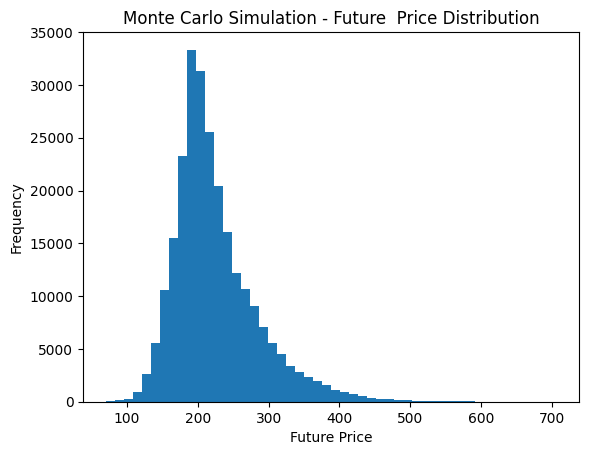

In [25]:
plt.hist(simulation_prices,bins=50)
plt.title("Monte Carlo Simulation - Future  Price Distribution")
plt.xlabel("Future Price")
plt.ylabel("Frequency")
plt.show()

CALCULATE VAR

In [28]:
VaR=np.percentile(simulation_prices,5)
print("Value at Risk (95% confidence):",VaR)

Value at Risk (95% confidence): 150.78306989074525


VAR VISUALIZATION

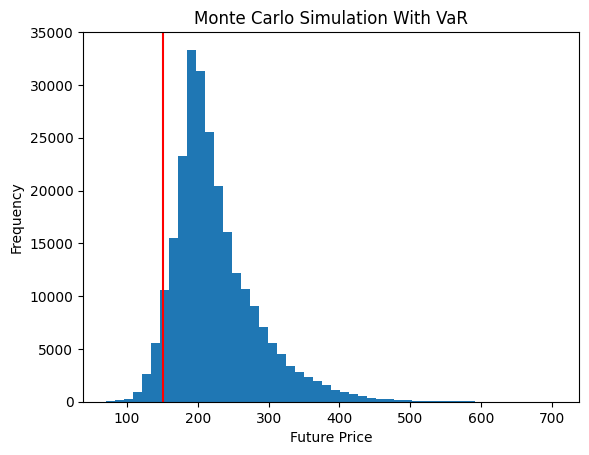

In [31]:
plt.hist(simulation_prices, bins=50)
plt.axvline(VaR,color="red")
plt.title("Monte Carlo Simulation With VaR")
plt.xlabel("Future Price")
plt.ylabel("Frequency")
plt.show()

EXPORT DATA

In [32]:
close_price.to_csv("stock_prices.csv")
returns.to_csv("daily_returns.csv")